In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_absolute_percentage_error
from xgboost import XGBRegressor

In [2]:
print("1. Memuat dan Membersihkan Data...")

dataset_path = 'dataset.csv'
df = pd.read_csv(dataset_path)

df['Harga'] = df['Harga'].str.replace('Rp', '', regex=False).str.replace(',', '', regex=False)
df['Harga'] = df['Harga'].str.strip().replace('-', np.nan)
df['Harga'] = df['Harga'].replace('', np.nan)

df_clean = df.dropna()

df_clean['Harga'] = df_clean['Harga'].astype(int)

X = df_clean.drop(columns=[df_clean.columns[-1]]) 
y = df_clean[df_clean.columns[-1]]

X = pd.get_dummies(X, drop_first=True)
print(f"Total data bersih: {X.shape[0]} baris, {X.shape[1]} fitur.")

1. Memuat dan Membersihkan Data...
Total data bersih: 36068 baris, 120 fitur.


C:\Users\ASUS\AppData\Local\Temp\ipykernel_54384\3653390061.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['Harga'] = df_clean['Harga'].astype(int)


In [3]:
y_log = np.log1p(y)

In [4]:
X_train, X_test, y_train_log, y_test_log = train_test_split(X, y_log, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Dimensi fitur sebelum PCA : 120 kolom
Dimensi fitur setelah PCA : 109 kolom (Mempertahankan 95% informasi)


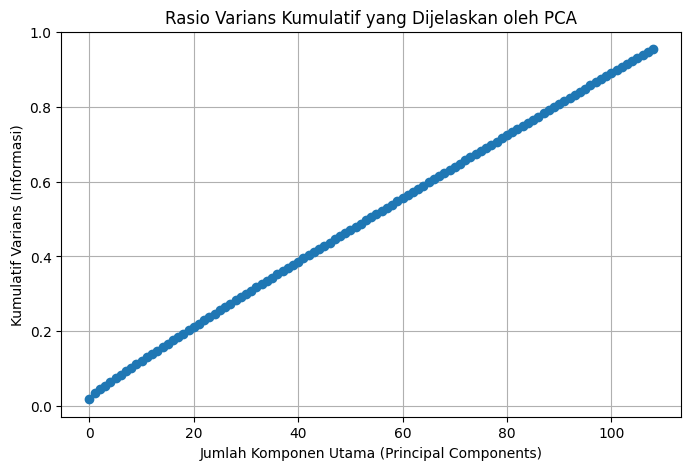

In [5]:
pca = PCA(n_components=0.95, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print(f"Dimensi fitur sebelum PCA : {X_train.shape[1]} kolom")
print(f"Dimensi fitur setelah PCA : {X_train_pca.shape[1]} kolom (Mempertahankan 95% informasi)")

# Visualisasi Kumulatif Varians PCA
plt.figure(figsize=(8, 5))
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o', linestyle='--')
plt.title('Rasio Varians Kumulatif yang Dijelaskan oleh PCA')
plt.xlabel('Jumlah Komponen Utama (Principal Components)')
plt.ylabel('Kumulatif Varians (Informasi)')
plt.grid(True)
plt.show()

In [6]:
xgb_model = XGBRegressor(
    n_estimators=200,      # Jumlah siklus perbaikan (jumlah pohon)
    learning_rate=0.1,     # Kecepatan belajar model (0.01 - 0.3 biasanya optimal)
    max_depth=6,           # Kedalaman maksimal pohon (jangan terlalu besar agar tidak overfitting)
    random_state=42,
    n_jobs=-1              # Gunakan seluruh core CPU agar cepat
)

# Latih model menggunakan data PCA dan Y logaritma
xgb_model.fit(X_train_pca, y_train_log)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=200,
             n_jobs=-1, num_parallel_tree=None, ...)

In [7]:
y_pred_log = xgb_model.predict(X_test_pca)

# KEMBALIKAN ke bentuk asli menggunakan np.expm1
y_pred_asli = np.expm1(y_pred_log)
y_test_asli = np.expm1(y_test_log)


          HASIL EVALUASI AKHIR XGBOOST                 

Root Mean Squared Error (RMSE)   : Rp 8,422.52
Mean Absolute Error (MAE)        : Rp 4,373.38
Mean Abs. Percentage Error (MAPE): 604988730379702272.00%
Skor R-Squared (R2)              : 93.15%


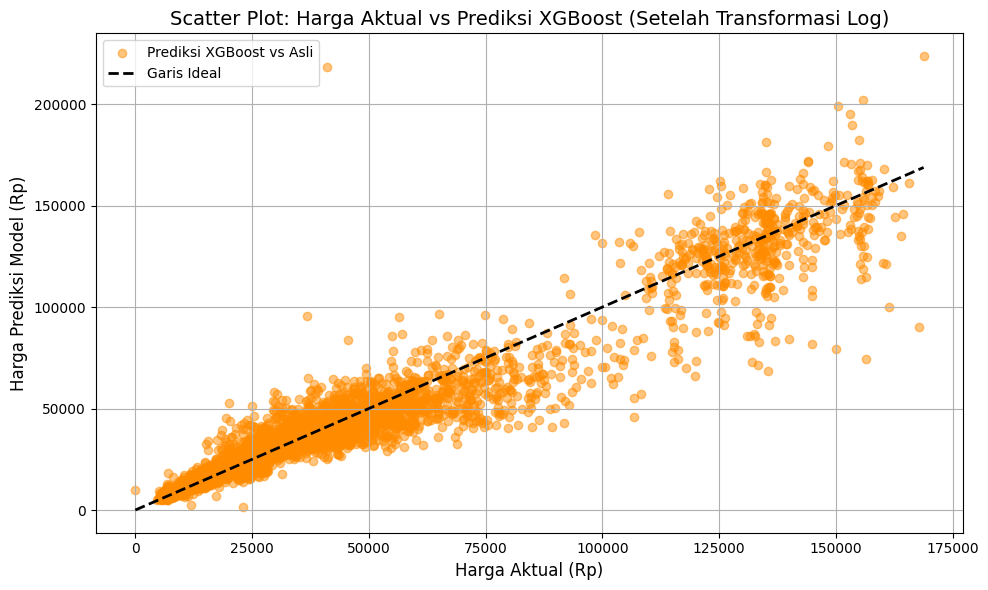

In [8]:
print("\n=======================================================")
print("          HASIL EVALUASI AKHIR XGBOOST                 ")
print("=======================================================\n")

mse = mean_squared_error(y_test_asli, y_pred_asli)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test_asli, y_pred_asli)
mape = mean_absolute_percentage_error(y_test_asli, y_pred_asli)
r2 = r2_score(y_test_asli, y_pred_asli)

print(f"Root Mean Squared Error (RMSE)   : Rp {rmse:,.2f}")
print(f"Mean Absolute Error (MAE)        : Rp {mae:,.2f}")
print(f"Mean Abs. Percentage Error (MAPE): {mape * 100:.2f}%")
print(f"Skor R-Squared (R2)              : {r2 * 100:.2f}%")

# VISUALISASI PERBANDINGAN HARGA
plt.figure(figsize=(10, 6))
# Kita gunakan warna orange/merah untuk membedakan visualisasi XGBoost dari Random Forest
plt.scatter(y_test_asli, y_pred_asli, alpha=0.5, color='darkorange', label='Prediksi XGBoost vs Asli')
plt.plot([y_test_asli.min(), y_test_asli.max()], [y_test_asli.min(), y_test_asli.max()], 'k--', lw=2, label='Garis Ideal')
plt.title('Scatter Plot: Harga Aktual vs Prediksi XGBoost (Setelah Transformasi Log)', fontsize=14)
plt.xlabel('Harga Aktual (Rp)', fontsize=12)
plt.ylabel('Harga Prediksi Model (Rp)', fontsize=12)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()